In [56]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import difflib

In [57]:
# Liste der CSV-Dateipfade
file_paths = [
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2017-CentralEuropeanStandardTime.csv",
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2018-WEuropeStandardTime.csv",
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2020-UTC.csv",
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2021-UTC.csv",
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2022-UTC.csv",
    r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\champions-league-2023-UTC.csv"
]

In [58]:
# Alle CSV-Dateien einlesen und in einer Liste speichern
dfs = [pd.read_csv(fp) for fp in file_paths]

# Zusammenfügen zu einem DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

In [59]:
combined_df

,Match Number,Round Number,Date,Location,Home Team,Away Team,Group,Result
0,1,1,12/09/2017 20:45,"Estádio da Luz, Lisbon",Benfica,CSKA Moscow,Group A,1 - 2
1,2,1,12/09/2017 20:45,"Old Trafford, Manchester",Manchester United,Basel,Group A,3 - 0
2,13,1,12/09/2017 20:45,"Allianz Arena, Munich",Bayern Munich,Anderlecht,Group B,3 - 0
3,14,1,12/09/2017 20:45,"Celtic Park, Glasgow",Celtic,Paris Saint-Germain,Group B,0 - 5
4,25,1,12/09/2017 20:45,"Stamford Bridge, London",Chelsea,Qarabag,Group C,6 - 0
...,...,...,...,...,...,...,...,...
745,121,SF Game 1,30/04/2024 19:00,Fußball Arena München,Bayern,Real Madrid,NaN,2 - 2
746,122,SF Game 1,01/05/2024 19:00,BVB Stadion Dortmund,Dortmund,Paris,NaN,1 - 0
747,123,SF Game 2,07/05/2024 19:00,Parc des Princes,Paris,Dortmund,NaN,0 - 1
748,124,SF Game 2,08/05/2024 19:00,Estadio Santiago Bernabéu,Real Madrid,Bayern,NaN,2 - 1


In [60]:
# Funktion zur Trennung der Ergebnisse
def split_result(result):
    try:
        home, away = result.strip().split('-')
        return int(home.strip()), int(away.strip())
    except:
        return None, None

# Aufteilen der 'Result'-Spalte
combined_df[['Home Goals', 'Away Goals']] = combined_df['Result'].apply(
    lambda x: pd.Series(split_result(x))
)

In [61]:
combined_df

,Match Number,Round Number,Date,Location,Home Team,Away Team,Group,Result,Home Goals,Away Goals
0,1,1,12/09/2017 20:45,"Estádio da Luz, Lisbon",Benfica,CSKA Moscow,Group A,1 - 2,1,2
1,2,1,12/09/2017 20:45,"Old Trafford, Manchester",Manchester United,Basel,Group A,3 - 0,3,0
2,13,1,12/09/2017 20:45,"Allianz Arena, Munich",Bayern Munich,Anderlecht,Group B,3 - 0,3,0
3,14,1,12/09/2017 20:45,"Celtic Park, Glasgow",Celtic,Paris Saint-Germain,Group B,0 - 5,0,5
4,25,1,12/09/2017 20:45,"Stamford Bridge, London",Chelsea,Qarabag,Group C,6 - 0,6,0
...,...,...,...,...,...,...,...,...,...,...
745,121,SF Game 1,30/04/2024 19:00,Fußball Arena München,Bayern,Real Madrid,NaN,2 - 2,2,2
746,122,SF Game 1,01/05/2024 19:00,BVB Stadion Dortmund,Dortmund,Paris,NaN,1 - 0,1,0
747,123,SF Game 2,07/05/2024 19:00,Parc des Princes,Paris,Dortmund,NaN,0 - 1,0,1
748,124,SF Game 2,08/05/2024 19:00,Estadio Santiago Bernabéu,Real Madrid,Bayern,NaN,2 - 1,2,1


In [62]:
# ############################################## 2017-18 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2017-CentralEuropeanStandardTime.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None
    
#     time.sleep(5)

# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2017_2018.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2017_2018.csv'")


In [63]:
df_2017_18 = pd.read_csv("ucl_elo_rankings_2017_2018.csv")

In [64]:
df_2017_18.head(50)

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Real Madrid,2072,NaN,2017-09-09,Zinédine Zidane (since 2016-01-05),2017-09-12
1,2,2 Barcelona,2033,NaN,2017-09-09,Ernesto Valverde (since 2017-07-01),2017-09-12
2,3,3 Bayern,1974,NaN,2017-09-09,Carlo Ancelotti (since 2016-07-01),2017-09-12
3,4,4 Juventus,1954,NaN,2017-09-09,Massimiliano Allegri (since 2014-07-16),2017-09-12
4,5,5 Atlético,1951,NaN,2017-09-09,Diego Simeone (since 2011-12-23),2017-09-12
5,6,6 Chelsea,1919,NaN,2017-09-09,Antonio Conte (since 2016-07-01),2017-09-12
6,7,7 Tottenham,1893,NaN,2017-09-09,Mauricio Pochettino (since 2014-07-01),2017-09-12
7,8,8 Paris SG,1889,NaN,2017-09-08,Unai Emery (since 2016-07-01),2017-09-12
8,9,9 Man City,1889,NaN,2017-09-09,Pep Guardiola (since 2016-07-01),2017-09-12
9,10,10 Napoli,1889,NaN,2017-09-10,Maurizio Sarri (since 2015-06-11),2017-09-12


In [65]:
# ############################################## 2018-19 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2018-WEuropeStandardTime.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None

#     time.sleep(5)
    
# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2018_2019.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2018_2019.csv'")


In [66]:
df_2018_19 = pd.read_csv("ucl_elo_rankings_2018_2019.csv")

In [67]:
df_2018_19

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Barcelona,2036,NaN,2018-09-15,Ernesto Valverde (since 2017-07-01),2018-09-18
1,2,2 Real Madrid,2024,NaN,2018-09-15,Julen Lopetegui (since 2018-07-01),2018-09-18
2,3,3 Man City,1977,NaN,2018-09-15,Pep Guardiola (since 2016-07-01),2018-09-18
3,4,4 Juventus,1966,NaN,2018-09-16,Massimiliano Allegri (since 2014-07-16),2018-09-18
4,5,5 Bayern,1960,NaN,2018-09-15,Niko Kovač (since 2018-07-01),2018-09-18
...,...,...,...,...,...,...,...
245,2,3 Liverpool,2003,NaN,2019-05-04,Jürgen Klopp (since 2015-10-08),2019-05-07
246,3,8 Tottenham,1877,NaN,2019-05-04,Mauricio Pochettino (since 2014-07-01),2019-05-07
247,4,13 Ajax,1836,NaN,2019-04-30,Erik ten Hag (since 2018-01-01),2019-05-07
248,1,1 Liverpool,2044,NaN,2019-05-12,Jürgen Klopp (since 2015-10-08),2019-06-01


In [68]:
# ############################################## 2020-21 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2020-UTC.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None
        
#     time.sleep(5)

# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2020_2021.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2020_2021.csv'")


In [69]:
df_2020_21 = pd.read_csv("ucl_elo_rankings_2020_2021.csv")

In [70]:
df_2020_21

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Bayern,2025,NaN,2020-10-17,Hansi Flick (since 2019-11-03),2020-10-20
1,2,2 Liverpool,1966,NaN,2020-10-17,Jürgen Klopp (since 2015-10-08),2020-10-20
2,3,3 Barcelona,1953,NaN,2020-10-17,Ronald Koeman (since 2020-08-19),2020-10-20
3,4,4 Man City,1950,NaN,2020-10-17,Pep Guardiola (since 2016-07-01),2020-10-20
4,5,5 Paris SG,1916,NaN,2020-10-16,Thomas Tuchel (since 2018-07-01),2020-10-20
...,...,...,...,...,...,...,...
245,2,4 Real Madrid,1943,NaN,2021-05-01,Zinédine Zidane (since 2019-03-11),2021-05-04
246,3,7 Chelsea,1900,NaN,2021-05-01,Thomas Tuchel (since 2021-01-26),2021-05-04
247,4,10 Paris SG,1881,NaN,2021-05-01,Mauricio Pochettino (since 2021-01-02),2021-05-04
248,1,1 Man City,2024,NaN,2021-05-23,Pep Guardiola (since 2016-07-01),2021-05-29


In [71]:
# ############################################## 2021-22 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2021-UTC.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None
        
#     time.sleep(5)

# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2021_2022.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2021_2022.csv'")


In [72]:
df_2021_22 = pd.read_csv("ucl_elo_rankings_2021_2022.csv")

In [73]:
df_2021_22.head(6)

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Man City,2016,NaN,2021-09-11,Pep Guardiola (since 2016-07-01),2021-09-14
1,2,2 Bayern,2000,NaN,2021-09-11,Julian Nagelsmann (since 2021-07-01),2021-09-14
2,3,3 Liverpool,1955,NaN,2021-09-12,Jürgen Klopp (since 2015-10-08),2021-09-14
3,4,4 Real Madrid,1945,NaN,2021-09-12,Carlo Ancelotti (since 2021-07-01),2021-09-14
4,5,5 Chelsea,1944,NaN,2021-09-11,Thomas Tuchel (since 2021-01-26),2021-09-14
5,6,6 Man United,1937,NaN,2021-09-11,Ole Gunnar Solskjær (since 2018-12-19),2021-09-14


In [74]:
# ############################################## 2022-23 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2022-UTC.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None
        
#     time.sleep(5)

# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2022_2023.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2022_2023.csv'")


In [75]:
df_2022_23 = pd.read_csv("ucl_elo_rankings_2022_2023.csv")

In [76]:
df_2022_23

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Man City,2025,NaN,2022-09-03,Pep Guardiola (since 2016-07-01),2022-09-06
1,2,2 Liverpool,2007,NaN,2022-09-03,Jürgen Klopp (since 2015-10-08),2022-09-06
2,3,3 Real Madrid,1996,NaN,2022-09-03,Carlo Ancelotti (since 2021-07-01),2022-09-06
3,4,4 Bayern,1962,NaN,2022-09-03,Julian Nagelsmann (since 2021-07-01),2022-09-06
4,5,5 Barcelona,1898,NaN,2022-09-03,Xavi (since 2021-11-08),2022-09-06
...,...,...,...,...,...,...,...
245,2,4 Real Madrid,1926,NaN,2023-05-13,Carlo Ancelotti (since 2021-07-01),2023-05-16
246,3,8 Inter,1884,NaN,2023-05-13,Simone Inzaghi (since 2021-07-01),2023-05-16
247,4,17 Milan,1820,NaN,2023-05-13,Stefano Pioli (since 2019-10-09),2023-05-16
248,1,1 Man City,2072,NaN,2023-05-28,Pep Guardiola (since 2016-07-01),2023-06-10


In [77]:
# ############################################## 2023-24 ##############################################

# # === 1. Champions-League-Daten laden ===
# df = pd.read_csv("champions-league-2023-UTC.csv")  # CSV-Datei mit allen Spielen

# # Datum bereinigen
# df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
# df_sorted = df.sort_values(by="Date")

# # === 2. Frühestes Spiel pro Runde extrahieren (alle Jahre!) ===
# first_dates_per_round = (
#     df_sorted.groupby("Round Number")["Date"]
#     .min()
#     .drop_duplicates()
#     .sort_values()
# )
# # keine Einschränkung mehr auf 2021
# date_list_for_urls = first_dates_per_round.dt.strftime("%Y-%m-%d").tolist()

# # === 3. Scrape alle Tabellen von den URLs ===
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# ucl_rankings = {}

# for date in date_list_for_urls:
#     url = f"http://clubelo.com/{date}/UCL/Ranking"
#     print(f"Scraping: {url}")
    
#     try:
#         response = requests.get(url, headers=headers)
#         soup = BeautifulSoup(response.text, "html.parser")
#         table = soup.find("table", class_="ranking")
        
#         if table:
#             df_table = pd.read_html(str(table))[0]
#             df_table["Date"] = date  # Spieldatum hinzufügen
#             ucl_rankings[date] = df_table
#         else:
#             print(f"Tabelle nicht gefunden für {date}")
#             ucl_rankings[date] = None
#     except Exception as e:
#         print(f"Fehler bei {date}: {e}")
#         ucl_rankings[date] = None
        
#     time.sleep(5)

# # === 4. Option: alle Tabellen kombinieren ===
# all_tables = [df for df in ucl_rankings.values() if df is not None]
# df_combined = pd.concat(all_tables, ignore_index=True)

# # Ausgabe: z. B. speichern als CSV
# df_combined.to_csv("ucl_elo_rankings_2023_2024.csv", index=False)
# print("Fertig! Tabellen gespeichert in 'ucl_elo_rankings_2023_2024.csv'")


In [78]:
df_2023_24 = pd.read_csv("ucl_elo_rankings_2023_2024.csv")

In [79]:
df_2023_24.head(5)

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date
0,1,1 Man City,2091,NaN,2023-09-16,Pep Guardiola (since 2016-07-01),2023-09-19
1,2,3 Bayern,1940,NaN,2023-09-15,Thomas Tuchel (since 2023-03-24),2023-09-19
2,3,4 Arsenal,1932,NaN,2023-09-17,Mikel Arteta (since 2019-12-22),2023-09-19
3,4,5 Real Madrid,1922,NaN,2023-09-17,Carlo Ancelotti (since 2021-07-01),2023-09-19
4,5,6 Inter,1909,NaN,2023-09-16,Simone Inzaghi (since 2021-07-01),2023-09-19


In [80]:
combined_df = pd.read_excel(r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\combined_df_full.xlsx")

In [81]:
combined_df

,Match Number,Round Number,Date,Location,Home Team,Away Team,Group,Result,Home Goals,Away Goals,Elo Home,Elo Away
0,1,1,2017-09-12 20:45:00,"Estádio da Luz, Lisbon",Benfica,CSKA Moscow,Group A,1 - 2,1,2,1797.0,1723.0
1,2,1,2017-09-12 20:45:00,"Old Trafford, Manchester",Manchester United,Basel,Group A,3 - 0,3,0,NaN,1621.0
2,13,1,2017-09-12 20:45:00,"Allianz Arena, Munich",Bayern Munich,Anderlecht,Group B,3 - 0,3,0,NaN,1656.0
3,14,1,2017-09-12 20:45:00,"Celtic Park, Glasgow",Celtic,Paris Saint-Germain,Group B,0 - 5,0,5,1615.0,NaN
4,25,1,2017-09-12 20:45:00,"Stamford Bridge, London",Chelsea,Qarabag,Group C,6 - 0,6,0,1919.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
745,121,SF Game 1,2024-04-30 19:00:00,Fußball Arena München,Bayern Munich,Real Madrid,NaN,2 - 2,2,2,1941.0,1984.0
746,122,SF Game 1,2024-05-01 19:00:00,BVB Stadion Dortmund,Borussia Dortmund,Paris Saint-Germain,NaN,1 - 0,1,0,1880.0,NaN
747,123,SF Game 2,2024-05-07 19:00:00,Parc des Princes,Paris Saint-Germain,Borussia Dortmund,NaN,0 - 1,0,1,NaN,1890.0
748,124,SF Game 2,2024-05-08 19:00:00,Estadio Santiago Bernabéu,Real Madrid,Bayern Munich,NaN,2 - 1,2,1,1988.0,1927.0


In [82]:
# ✅ Excel-Datei neu laden (Pfad ggf. anpassen zu deinem Speicherort)
elo_data_merged = pd.read_excel(r"C:\Users\salim\Downloads\Data Science Bachelor\Uni_Module\V.Sportdaten\code\elo_data_merged_2017_2024.xlsx")

In [83]:
elo_data_merged

,Rank,Club,Elo,Unnamed: 3,Last Match,Coach,Date,Clean Club
0,1,1 Real Madrid,2072,NaN,2017-09-09,Zinédine Zidane (since 2016-01-05),2017-09-12,real madrid
1,2,2 Barcelona,2033,NaN,2017-09-09,Ernesto Valverde (since 2017-07-01),2017-09-12,barcelona
2,3,3 Bayern Munich,1974,NaN,2017-09-09,Carlo Ancelotti (since 2016-07-01),2017-09-12,Bayern Munich
3,4,4 Juventus,1954,NaN,2017-09-09,Massimiliano Allegri (since 2014-07-16),2017-09-12,juventus
4,5,5 Atlético Madrid,1951,NaN,2017-09-09,Diego Simeone (since 2011-12-23),2017-09-12,Atlético Madrid
...,...,...,...,...,...,...,...,...
1495,2,6 Bayern Munich,1927,NaN,2024-05-04,Thomas Tuchel (since 2023-03-24),2024-05-07,Bayern Munich
1496,3,7 Paris Saint-Germain,1910,NaN,2024-05-01,Luis Enrique (since 2023-07-05),2024-05-07,Paris Saint-Germain
1497,4,9 Borussia Dortmund,1890,NaN,2024-05-04,Edin Terzić (since 2022-05-24),2024-05-07,Borussia Dortmund
1498,1,2 Real Madrid,1988,NaN,2024-05-25,Carlo Ancelotti (since 2021-07-01),2024-06-01,real madrid


In [84]:
import pandas as pd
import re

# Datum vorbereiten
elo_data_merged["Date"] = pd.to_datetime(elo_data_merged["Date"])
combined_df["Date"] = pd.to_datetime(combined_df["Date"], dayfirst=True)

# Clubnamen bereinigen (z.B. '1 Man City' → 'man city')
def clean_club_name(name):
    name = str(name)
    name = re.sub(r"^\d+\s+", "", name)
    return name.strip().lower()

# Clean Club-Spalte in elo_data_merged für einfaches Matching
elo_data_merged["Clean Club"] = elo_data_merged["Club"].apply(clean_club_name)

# Vorbereitung: leere Spalten für Elo Home & Elo Away in combined_df
combined_df["Elo Home"] = None
combined_df["Elo Away"] = None

# Matching & Elo-Zuweisung für combined_df
for idx, row in combined_df.iterrows():
    match_date = row["Date"]
    home_team = clean_club_name(row["Home Team"])
    away_team = clean_club_name(row["Away Team"])

    # Den letzten Elo-Snapshot vor (oder am) Spieltag finden
    elo_date = elo_data_merged[elo_data_merged["Date"] <= match_date]["Date"].max()

    if pd.isna(elo_date):
        continue

    snapshot = elo_data_merged[elo_data_merged["Date"] == elo_date]

    # Elo für Heimteam finden
    home_row = snapshot[snapshot["Clean Club"] == home_team]
    if not home_row.empty:
        combined_df.at[idx, "Elo Home"] = home_row.iloc[0]["Elo"]

    # Elo für Auswärtsteam finden
    away_row = snapshot[snapshot["Clean Club"] == away_team]
    if not away_row.empty:
        combined_df.at[idx, "Elo Away"] = away_row.iloc[0]["Elo"]


In [85]:
# Ergebnis anzeigen
combined_df.head(50)

,Match Number,Round Number,Date,Location,Home Team,Away Team,Group,Result,Home Goals,Away Goals,Elo Home,Elo Away
0,1,1,2017-09-12 20:45:00,"Estádio da Luz, Lisbon",Benfica,CSKA Moscow,Group A,1 - 2,1,2,1797,1723
1,2,1,2017-09-12 20:45:00,"Old Trafford, Manchester",Manchester United,Basel,Group A,3 - 0,3,0,1879,1621
2,13,1,2017-09-12 20:45:00,"Allianz Arena, Munich",Bayern Munich,Anderlecht,Group B,3 - 0,3,0,1974,1656
3,14,1,2017-09-12 20:45:00,"Celtic Park, Glasgow",Celtic,Paris Saint-Germain,Group B,0 - 5,0,5,1615,1889
4,25,1,2017-09-12 20:45:00,"Stamford Bridge, London",Chelsea,Qarabag,Group C,6 - 0,6,0,1919,1511
5,26,1,2017-09-12 20:45:00,"Stadio Olimpico, Rome",Roma,Atlético Madrid,Group C,0 - 0,0,0,1832,1951
6,37,1,2017-09-12 20:45:00,"Camp Nou, Barcelona",Barcelona,Juventus,Group D,3 - 0,3,0,2033,1954
7,38,1,2017-09-12 20:45:00,"Karaiskakis Stadium, Piraeus",Olympiacos,Sporting CP,Group D,2 - 3,2,3,1660,1720
8,49,1,2017-09-13 20:45:00,"Ljudski vrt, Maribor",Maribor,Spartak Moscow,Group E,1 - 1,1,1,1434,1659
9,50,1,2017-09-13 20:45:00,"Anfield, Liverpool",Liverpool,Sevilla,Group E,2 - 2,2,2,1852,1829


In [86]:
# Filter: Zeilen mit fehlenden Werten in 'Elo Home' oder 'Elo Away'
missing_elos = combined_df[
    combined_df["Elo Home"].isna() | combined_df["Elo Away"].isna()
]

# Ergebnis als DataFrame anzeigen
print(f"Es gibt {missing_elos.shape[0]} Zeilen mit fehlenden Elo-Werten")

Es gibt 0 Zeilen mit fehlenden Elo-Werten


In [87]:
# Neue DataFrame-Liste zum Sammeln
expanded_rows = []

for idx, row in combined_df.iterrows():
    if pd.isna(row["Elo Home"]) or pd.isna(row["Elo Away"]):
        continue  # Zeilen mit fehlenden Elo-Werten überspringen

    # Elo-Differenzen
    elo_diff_home = row["Elo Home"] - row["Elo Away"]
    elo_diff_away = row["Elo Away"] - row["Elo Home"]

    # Prüfen ob Final → Dummy Home auf 0 setzen
    is_final = str(row["Round Number"]).strip().lower() == "final"
    home_dummy = 0 if is_final else 1
    away_dummy = 0  # Auswärtsteam bleibt immer 0

    # Home-Team als Zeile
    expanded_rows.append({
        "Date": row["Date"],
        "Team": row["Home Team"],
        "Goals": row["Home Goals"],
        "Elo_Diff": elo_diff_home,
        "Home": home_dummy
    })

    # Away-Team als Zeile
    expanded_rows.append({
        "Date": row["Date"],
        "Team": row["Away Team"],
        "Goals": row["Away Goals"],
        "Elo_Diff": elo_diff_away,
        "Home": away_dummy
    })

# DataFrame daraus machen
model_df = pd.DataFrame(expanded_rows)

# Ergebnis anzeigen
model_df.head()


,Date,Team,Goals,Elo_Diff,Home
0,2017-09-12 20:45:00,Benfica,1,74,1
1,2017-09-12 20:45:00,CSKA Moscow,2,-74,0
2,2017-09-12 20:45:00,Manchester United,3,258,1
3,2017-09-12 20:45:00,Basel,0,-258,0
4,2017-09-12 20:45:00,Bayern Munich,3,318,1


In [88]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Poisson Regression mit Log-Link
poisson_model = smf.glm(
    formula="Goals ~ Elo_Diff + Home",
    data=model_df,
    family=sm.families.Poisson()
).fit()

# Ergebnisse anzeigen
print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Goals   No. Observations:                 1500
Model:                            GLM   Df Residuals:                     1497
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2249.0
Date:                Mon, 08 Sep 2025   Deviance:                       1736.5
Time:                        17:54:35   Pearson chi2:                 1.52e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2146
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2289      0.032      7.090      0.0

In [89]:
import pandas as pd

# Liste der Teams und zugehöriger Töpfe gemäß UEFA-Auslosung 2023/24
teams_with_pots = [
    # Pot 1
    ("Man City", 1),
    ("Sevilla", 1),
    ("Barcelona", 1),
    ("Napoli", 1),
    ("Bayern", 1),
    ("Paris SG", 1),
    ("Benfica", 1),
    ("Feyenoord", 1),
    # Pot 2
    ("Real Madrid", 2),
    ("Man United", 2),
    ("Inter", 2),
    ("Dortmund", 2),
    ("Atlético", 2),
    ("RB Leipzig", 2),
    ("Porto", 2),
    ("Arsenal", 2),
    # Pot 3
    ("Shakhtar", 3),
    ("Salzburg", 3),
    ("Milan", 3),
    ("Braga", 3),
    ("PSV", 3),
    ("Lazio", 3),
    ("Crvena Zvezda", 3),
    ("Copenhagen", 3),
    # Pot 4
    ("Young Boys", 4),
    ("Real Sociedad", 4),
    ("Galatasaray", 4),
    ("Celtic", 4),
    ("Newcastle", 4),
    ("Union Berlin", 4),
    ("Antwerp", 4),
    ("Lens", 4),
]

# Elo-Werte der Teams (hypothetisch oder geschätzt)
elo_dict = {
    "Man City": 2091, "Sevilla": 1733, "Barcelona": 1878, "Napoli": 1892,
    "Bayern": 1940, "Paris SG": 1801, "Benfica": 1806, "Feyenoord": 1753,
    "Real Madrid": 1922, "Man United": 1847, "Inter": 1909, "Dortmund": 1841,
    "Atlético": 1838, "RB Leipzig": 1841, "Porto": 1825, "Arsenal": 1932,
    "Shakhtar": 1591, "Salzburg": 1730, "Milan": 1841, "Braga": 1662,
    "PSV": 1778, "Lazio": 1760, "Crvena Zvezda": 1573, "Copenhagen": 1632,
    "Young Boys": 1630, "Real Sociedad": 1772, "Galatasaray": 1696,
    "Celtic": 1634, "Newcastle": 1872, "Union Berlin": 1735,
    "Antwerp": 1656, "Lens": 1709
}

# DataFrame erstellen
df_pots = pd.DataFrame(teams_with_pots, columns=["Club", "Pot"])
df_pots["Elo"] = df_pots["Club"].map(elo_dict)

In [90]:
df_pots

,Club,Pot,Elo
0,Man City,1,2091
1,Sevilla,1,1733
2,Barcelona,1,1878
3,Napoli,1,1892
4,Bayern,1,1940
5,Paris SG,1,1801
6,Benfica,1,1806
7,Feyenoord,1,1753
8,Real Madrid,2,1922
9,Man United,2,1847


In [91]:
# Mapping der Clubs zu ihren Ländern (basierend auf 2023/24)
club_to_country = {
    "Man City": "ENG", "Sevilla": "ESP", "Barcelona": "ESP", "Napoli": "ITA", "Bayern": "GER", "Paris SG": "FRA", "Benfica": "POR", "Feyenoord": "NED",
    "Real Madrid": "ESP", "Man United": "ENG", "Inter": "ITA", "Dortmund": "GER", "Atlético": "ESP", "RB Leipzig": "GER", "Porto": "POR", "Arsenal": "ENG",
    "Shakhtar": "UKR", "Salzburg": "AUT", "Milan": "ITA", "Braga": "POR", "PSV": "NED", "Lazio": "ITA", "Crvena Zvezda": "SRB", "Copenhagen": "DEN",
    "Young Boys": "SUI", "Real Sociedad": "ESP", "Galatasaray": "TUR", "Celtic": "SCO", "Newcastle": "ENG", "Union Berlin": "GER", "Antwerp": "BEL", "Lens": "FRA"
}

# Country-Spalte ergänzen
df_pots["Country"] = df_pots["Club"].map(club_to_country)


In [92]:
import random

# Gruppen initialisieren
groups = {f"Group {chr(65+i)}": [] for i in range(8)}

# Zuweisung je Topf
for pot_num in range(1, 5):
    pot_teams = df_pots[df_pots["Pot"] == pot_num].copy()
    pot_teams = pot_teams.sample(frac=1).to_dict("records")  # zufällig mischen

    for team in pot_teams:
        assigned = False
        group_names = list(groups.keys())
        random.shuffle(group_names)

        for group_name in group_names:
            existing_countries = [t["Country"] for t in groups[group_name]]
            if len(groups[group_name]) < pot_num and team["Country"] not in existing_countries:
                groups[group_name].append(team)
                assigned = True
                break

        if not assigned:
            raise Exception(f"❌ Kein gültiger Platz gefunden für {team['Club']} ({team['Country']}) aus Pot {pot_num}")

# Ergebnis in DataFrame umwandeln
group_assignments = []
for group, teams in groups.items():
    for team in teams:
        group_assignments.append({
            "Group": group,
            "Club": team["Club"],
            "Country": team["Country"],
            "Pot": team["Pot"],
            "Elo": team["Elo"]
        })

df_group_draw = pd.DataFrame(group_assignments).sort_values(by=["Group", "Pot"]).reset_index(drop=True)

# Anzeigen
print("✅ UEFA-konforme Gruppenauslosung abgeschlossen:")
display(df_group_draw)


✅ UEFA-konforme Gruppenauslosung abgeschlossen:


,Group,Club,Country,Pot,Elo
0,Group A,Feyenoord,NED,1,1753
1,Group A,Atlético,ESP,2,1838
2,Group A,Copenhagen,DEN,3,1632
3,Group A,Lens,FRA,4,1709
4,Group B,Napoli,ITA,1,1892
5,Group B,Porto,POR,2,1825
6,Group B,PSV,NED,3,1778
7,Group B,Real Sociedad,ESP,4,1772
8,Group C,Paris SG,FRA,1,1801
9,Group C,Dortmund,GER,2,1841


In [93]:
import numpy as np
from itertools import combinations
import math

# Poisson-Koeffizienten aus deinem Modell
beta0 = 0.2289
beta_elo = 0.0020
beta_home = 0.2019

# Erwartete Tore berechnen
def expected_goals(elo_diff, home_dummy):
    return math.exp(beta0 + beta_elo * elo_diff + beta_home * home_dummy)

# Gruppierung nach Gruppenname
grouped = df_group_draw.groupby("Group")
match_results = []

# Simulation der Hin- und Rückspiele
for group_name, teams in grouped:
    for team1, team2 in combinations(teams.to_dict("records"), 2):
        elo1, elo2 = team1["Elo"], team2["Elo"]

        # Hinspiel: team1 zuhause
        lam_home = expected_goals(elo1 - elo2, 1)
        lam_away = expected_goals(elo2 - elo1, 0)
        goals_home = np.random.poisson(lam_home)
        goals_away = np.random.poisson(lam_away)
        match_results.append({
            "Group": group_name,
            "Home": team1["Club"],
            "Away": team2["Club"],
            "Goals Home": goals_home,
            "Goals Away": goals_away
        })

        # Rückspiel: team2 zuhause
        lam_home = expected_goals(elo2 - elo1, 1)
        lam_away = expected_goals(elo1 - elo2, 0)
        goals_home = np.random.poisson(lam_home)
        goals_away = np.random.poisson(lam_away)
        match_results.append({
            "Group": group_name,
            "Home": team2["Club"],
            "Away": team1["Club"],
            "Goals Home": goals_home,
            "Goals Away": goals_away
        })

# In DataFrame umwandeln
df_matches = pd.DataFrame(match_results)

# Punkte & Tordifferenz berechnen
points = {}
goal_diff = {}

for _, row in df_matches.iterrows():
    h, a = row["Home"], row["Away"]
    gh, ga = row["Goals Home"], row["Goals Away"]

    if gh > ga:
        points[h] = points.get(h, 0) + 3
    elif gh < ga:
        points[a] = points.get(a, 0) + 3
    else:
        points[h] = points.get(h, 0) + 1
        points[a] = points.get(a, 0) + 1

    goal_diff[h] = goal_diff.get(h, 0) + (gh - ga)
    goal_diff[a] = goal_diff.get(a, 0) + (ga - gh)

# Ergebnisse mit Teams zusammenführen
df_group_draw["Points"] = df_group_draw["Club"].map(points).fillna(0)
df_group_draw["Goal Diff"] = df_group_draw["Club"].map(goal_diff).fillna(0)

# Nach Gruppe, Punkte, Tordifferenz sortieren
df_group_final = (
    df_group_draw
    .sort_values(by=["Group", "Points", "Goal Diff"], ascending=[True, False, False])
    .reset_index(drop=True)
)

# Ergebnisse anzeigen
display(df_group_final)


,Group,Club,Country,Pot,Elo,Points,Goal Diff
0,Group A,Feyenoord,NED,1,1753,18.0,10
1,Group A,Atlético,ESP,2,1838,12.0,4
2,Group A,Lens,FRA,4,1709,6.0,-1
3,Group A,Copenhagen,DEN,3,1632,0.0,-13
4,Group B,Napoli,ITA,1,1892,10.0,2
5,Group B,PSV,NED,3,1778,9.0,-2
6,Group B,Porto,POR,2,1825,8.0,2
7,Group B,Real Sociedad,ESP,4,1772,5.0,-2
8,Group C,Dortmund,GER,2,1841,13.0,6
9,Group C,Paris SG,FRA,1,1801,9.0,7


In [94]:
import numpy as np
import random
import math
import pandas as pd

# === Poisson-Funktionen basierend auf deinen geschätzten Betas ===
BETA0 = 0.2289
BETA_ELO = 0.0020
BETA_HOME = 0.2019

def expected_goals(elo_diff, home):
    return math.exp(BETA0 + BETA_ELO * elo_diff + BETA_HOME * home)

def simulate_match(home_elo, away_elo):
    elo_diff_home = home_elo - away_elo
    lam_home = expected_goals(elo_diff_home, home=1)
    lam_away = expected_goals(-elo_diff_home, home=0)
    return np.random.poisson(lam_home), np.random.poisson(lam_away)

# === Top 2 Teams pro Gruppe bestimmen ===
df_group_draw["Points"] = df_group_draw["Points"].fillna(0)
top2 = (
    df_group_draw
    .sort_values(by=["Group", "Points", "Goal Diff"], ascending=[True, False, False])
    .groupby("Group")
    .head(2)
)

group_winners = top2.groupby("Group").nth(0).reset_index(drop=True)
group_runners_up = top2.groupby("Group").nth(1).reset_index(drop=True)

# === Paarungen unter Beachtung der UEFA-Regeln (nicht gleiche Gruppe/Land) ===
pairings = []
used_runners = set()

for _, winner in group_winners.iterrows():
    opponents = group_runners_up[
        (group_runners_up["Country"] != winner["Country"]) &
        (group_runners_up["Group"] != winner["Group"]) &
        (~group_runners_up["Club"].isin(used_runners))
    ]
    if opponents.empty:
        continue
    selected = opponents.sample(1).iloc[0]
    used_runners.add(selected["Club"])

    pairings.append({
        "Team 1": winner["Club"],
        "Team 2": selected["Club"],
        "Elo 1": winner["Elo"],
        "Elo 2": selected["Elo"]
    })

df_r16_pairs = pd.DataFrame(pairings)

# === Spiele simulieren (2 Legs) ===
results = []
for _, row in df_r16_pairs.iterrows():
    team1, team2 = row["Team 1"], row["Team 2"]
    elo1, elo2 = row["Elo 1"], row["Elo 2"]

    # Leg 1 (Team1 auswärts)
    g1_home, g1_away = simulate_match(elo2, elo1)
    # Leg 2 (Team1 zuhause)
    g2_home, g2_away = simulate_match(elo1, elo2)

    total1 = g1_away + g2_home
    total2 = g1_home + g2_away

    if total1 > total2:
        winner = team1
    elif total2 > total1:
        winner = team2
    else:
        winner = random.choice([team1, team2])

    results.append({
        "Team 1": team1,
        "Team 2": team2,
        "1st Leg": f"{g1_home} - {g1_away}",
        "2nd Leg": f"{g2_home} - {g2_away}",
        "Total": f"{total1} - {total2}",
        "Winner": winner
    })

df_r16_results = pd.DataFrame(results)
display(df_r16_results)


,Team 1,Team 2,1st Leg,2nd Leg,Total,Winner
0,Feyenoord,Inter,2 - 0,2 - 0,2 - 2,Inter
1,Napoli,Man United,2 - 0,3 - 1,3 - 3,Man United
2,Dortmund,Real Madrid,3 - 1,0 - 0,1 - 3,Real Madrid
3,Bayern,Barcelona,0 - 4,1 - 0,5 - 0,Bayern
4,Arsenal,Atlético,3 - 0,2 - 2,2 - 5,Atlético
5,Man City,Paris SG,0 - 0,2 - 1,2 - 1,Man City
6,Milan,PSV,1 - 1,1 - 0,2 - 1,Milan
7,RB Leipzig,Lazio,0 - 0,2 - 0,2 - 0,RB Leipzig


In [95]:
# === Gewinner aus Achtelfinale extrahieren ===
quarter_finalists = df_r16_results["Winner"].tolist()
random.shuffle(quarter_finalists)  # zufällige Paarung

# === Paarungen erstellen ===
qf_pairs = []
for i in range(0, len(quarter_finalists), 2):
    team1 = quarter_finalists[i]
    team2 = quarter_finalists[i + 1]
    
    elo1 = df_group_draw[df_group_draw["Club"] == team1]["Elo"].values[0]
    elo2 = df_group_draw[df_group_draw["Club"] == team2]["Elo"].values[0]
    
    qf_pairs.append({
        "Team 1": team1,
        "Team 2": team2,
        "Elo 1": elo1,
        "Elo 2": elo2
    })

df_qf_pairs = pd.DataFrame(qf_pairs)

# === Spiele simulieren (2 Legs) ===
qf_results = []
for _, row in df_qf_pairs.iterrows():
    team1, team2 = row["Team 1"], row["Team 2"]
    elo1, elo2 = row["Elo 1"], row["Elo 2"]

    # Leg 1 (Team1 auswärts)
    g1_home, g1_away = simulate_match(elo2, elo1)
    # Leg 2 (Team1 zuhause)
    g2_home, g2_away = simulate_match(elo1, elo2)

    total1 = g1_away + g2_home
    total2 = g1_home + g2_away

    if total1 > total2:
        winner = team1
    elif total2 > total1:
        winner = team2
    else:
        winner = random.choice([team1, team2])

    qf_results.append({
        "Team 1": team1,
        "Team 2": team2,
        "1st Leg": f"{g1_home} - {g1_away}",
        "2nd Leg": f"{g2_home} - {g2_away}",
        "Total": f"{total1} - {total2}",
        "Winner": winner
    })

df_qf_results = pd.DataFrame(qf_results)
display(df_qf_results)


,Team 1,Team 2,1st Leg,2nd Leg,Total,Winner
0,RB Leipzig,Man United,1 - 0,0 - 3,0 - 4,Man United
1,Real Madrid,Inter,1 - 2,2 - 1,4 - 2,Real Madrid
2,Bayern,Atlético,4 - 0,2 - 1,2 - 5,Atlético
3,Milan,Man City,2 - 0,1 - 2,1 - 4,Man City


In [96]:
# === Gewinner aus Viertelfinale extrahieren ===
semi_finalists = df_qf_results["Winner"].tolist()
random.shuffle(semi_finalists)

# === Paarungen erstellen ===
sf_pairs = []
for i in range(0, len(semi_finalists), 2):
    team1 = semi_finalists[i]
    team2 = semi_finalists[i + 1]
    
    elo1 = df_group_draw[df_group_draw["Club"] == team1]["Elo"].values[0]
    elo2 = df_group_draw[df_group_draw["Club"] == team2]["Elo"].values[0]
    
    sf_pairs.append({
        "Team 1": team1,
        "Team 2": team2,
        "Elo 1": elo1,
        "Elo 2": elo2
    })

df_sf_pairs = pd.DataFrame(sf_pairs)

# === Spiele simulieren (2 Legs) ===
sf_results = []
for _, row in df_sf_pairs.iterrows():
    team1, team2 = row["Team 1"], row["Team 2"]
    elo1, elo2 = row["Elo 1"], row["Elo 2"]

    # Leg 1 (Team1 auswärts)
    g1_home, g1_away = simulate_match(elo2, elo1)
    # Leg 2 (Team1 zuhause)
    g2_home, g2_away = simulate_match(elo1, elo2)

    total1 = g1_away + g2_home
    total2 = g1_home + g2_away

    if total1 > total2:
        winner = team1
    elif total2 > total1:
        winner = team2
    else:
        winner = random.choice([team1, team2])

    sf_results.append({
        "Team 1": team1,
        "Team 2": team2,
        "1st Leg": f"{g1_home} - {g1_away}",
        "2nd Leg": f"{g2_home} - {g2_away}",
        "Total": f"{total1} - {total2}",
        "Winner": winner
    })

df_sf_results = pd.DataFrame(sf_results)
display(df_sf_results)


,Team 1,Team 2,1st Leg,2nd Leg,Total,Winner
0,Real Madrid,Atlético,2 - 4,2 - 0,6 - 2,Real Madrid
1,Man City,Man United,1 - 5,4 - 1,9 - 2,Man City


In [97]:
# === Finalisten extrahieren ===
final_teams = df_sf_results["Winner"].tolist()
final_team1, final_team2 = final_teams[0], final_teams[1]

elo1 = df_group_draw[df_group_draw["Club"] == final_team1]["Elo"].values[0]
elo2 = df_group_draw[df_group_draw["Club"] == final_team2]["Elo"].values[0]

# Erwartete Tore (neutraler Boden – kein Heimvorteil)
lambda_1 = expected_goals(elo1 - elo2, 0)
lambda_2 = expected_goals(elo2 - elo1, 0)

# Simulation
goals_1 = np.random.poisson(lambda_1)
goals_2 = np.random.poisson(lambda_2)

# Entscheidung
if goals_1 > goals_2:
    winner = final_team1
elif goals_2 > goals_1:
    winner = final_team2
else:
    winner = random.choice([final_team1, final_team2])  # Entscheidung per Zufall bei Unentschieden

# Ergebnis anzeigen
final_result = pd.DataFrame([{
    "Finalist 1": final_team1,
    "Finalist 2": final_team2,
    "Goals 1": goals_1,
    "Goals 2": goals_2,
    "Winner": winner
}])

display(final_result)


,Finalist 1,Finalist 2,Goals 1,Goals 2,Winner
0,Real Madrid,Man City,0,2,Man City


In [98]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations

# Deine geschätzten Koeffizienten (wie im Bild)
BETA_0 = 0.2289
BETA_ELO = 0.0020
BETA_HOME = 0.2019

# Erwartete Tore
def expected_goals(elo_diff, home):
    return math.exp(BETA_0 + BETA_ELO * elo_diff + BETA_HOME * home)

# Gruppenphase simulieren (Hin- und Rückspiel)
def simulate_group_stage(df_group_draw):
    results = []
    for group in df_group_draw["Group"].unique():
        teams = df_group_draw[df_group_draw["Group"] == group].reset_index(drop=True)
        for i in range(4):
            for j in range(i+1, 4):
                team1, team2 = teams.iloc[i], teams.iloc[j]
                # Hinspiel
                lam1 = expected_goals(team1["Elo"] - team2["Elo"], 1)
                lam2 = expected_goals(team2["Elo"] - team1["Elo"], 0)
                g1 = np.random.poisson(lam1)
                g2 = np.random.poisson(lam2)
                results.append((group, team1["Club"], team2["Club"], g1, g2))
                # Rückspiel
                lam1 = expected_goals(team2["Elo"] - team1["Elo"], 1)
                lam2 = expected_goals(team1["Elo"] - team2["Elo"], 0)
                g1 = np.random.poisson(lam1)
                g2 = np.random.poisson(lam2)
                results.append((group, team2["Club"], team1["Club"], g1, g2))
    return pd.DataFrame(results, columns=["Group", "Home", "Away", "Goals Home", "Goals Away"])

# Punkte berechnen
def compute_group_points(matches):
    points = {}
    goal_diff = {}
    for _, row in matches.iterrows():
        h, a = row["Home"], row["Away"]
        gh, ga = row["Goals Home"], row["Goals Away"]
        points[h] = points.get(h, 0)
        points[a] = points.get(a, 0)
        goal_diff[h] = goal_diff.get(h, 0)
        goal_diff[a] = goal_diff.get(a, 0)

        if gh > ga:
            points[h] += 3
        elif gh < ga:
            points[a] += 3
        else:
            points[h] += 1
            points[a] += 1
        goal_diff[h] += gh - ga
        goal_diff[a] += ga - gh
    return points, goal_diff

# Achtelfinale simulieren
def simulate_knockout_round(teams, df_group_draw):
    random.shuffle(teams)
    next_round = []
    for i in range(0, len(teams), 2):
        t1, t2 = teams[i], teams[i+1]
        elo1 = df_group_draw[df_group_draw["Club"] == t1]["Elo"].values[0]
        elo2 = df_group_draw[df_group_draw["Club"] == t2]["Elo"].values[0]

        # Hinspiel: t1 Heim
        g1 = np.random.poisson(expected_goals(elo1 - elo2, 1))
        g2 = np.random.poisson(expected_goals(elo2 - elo1, 0))
        # Rückspiel: t2 Heim
        g3 = np.random.poisson(expected_goals(elo2 - elo1, 1))
        g4 = np.random.poisson(expected_goals(elo1 - elo2, 0))

        total1 = g1 + g4
        total2 = g2 + g3

        if total1 > total2:
            next_round.append(t1)
        elif total2 > total1:
            next_round.append(t2)
        else:
            next_round.append(random.choice([t1, t2]))  # Bei Gleichstand

    return next_round

# Finale simulieren (1 Spiel, neutraler Boden)
def simulate_final(team1, team2, df_group_draw):
    elo1 = df_group_draw[df_group_draw["Club"] == team1]["Elo"].values[0]
    elo2 = df_group_draw[df_group_draw["Club"] == team2]["Elo"].values[0]
    g1 = np.random.poisson(expected_goals(elo1 - elo2, 0))
    g2 = np.random.poisson(expected_goals(elo2 - elo1, 0))
    if g1 > g2:
        return team1
    elif g2 > g1:
        return team2
    return random.choice([team1, team2])

# === Haupt-Simulationsschleife ===
from collections import Counter

winner_counts = Counter()

for sim in range(10000):
    # Gruppenphase
    group_matches = simulate_group_stage(df_group_draw)
    pts, gd = compute_group_points(group_matches)

    # Tabelle
    teams_in_groups = df_group_draw.copy()
    teams_in_groups["Points"] = teams_in_groups["Club"].map(pts).fillna(0)
    teams_in_groups["GD"] = teams_in_groups["Club"].map(gd).fillna(0)

    qualified = []
    for group in teams_in_groups["Group"].unique():
        top2 = (
            teams_in_groups[teams_in_groups["Group"] == group]
            .sort_values(by=["Points", "GD"], ascending=False)
            .head(2)["Club"]
            .tolist()
        )
        qualified.extend(top2)

    # K.O.-Phase
    qf = simulate_knockout_round(qualified, df_group_draw)
    sf = simulate_knockout_round(qf, df_group_draw)
    finalists = simulate_knockout_round(sf, df_group_draw)
    winner = simulate_final(finalists[0], finalists[1], df_group_draw)

    winner_counts[winner] += 1

# Ergebnisse anzeigen
results_df = pd.DataFrame.from_dict(winner_counts, orient="index", columns=["Wins"]).sort_values(by="Wins", ascending=False)
print("🏆 Final Winners after 10,000 Simulations:")
display(results_df)

🏆 Final Winners after 10,000 Simulations:


,Wins
Man City,4517
Bayern,957
Real Madrid,752
Arsenal,749
Inter,586
Napoli,408
Barcelona,333
Newcastle,269
Dortmund,219
Man United,210


## visualisierungen

C:\Users\salim\AppData\Local\Temp\ipykernel_5816\2501197894.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Team", y="Win Probability (%)", palette="Blues_d")


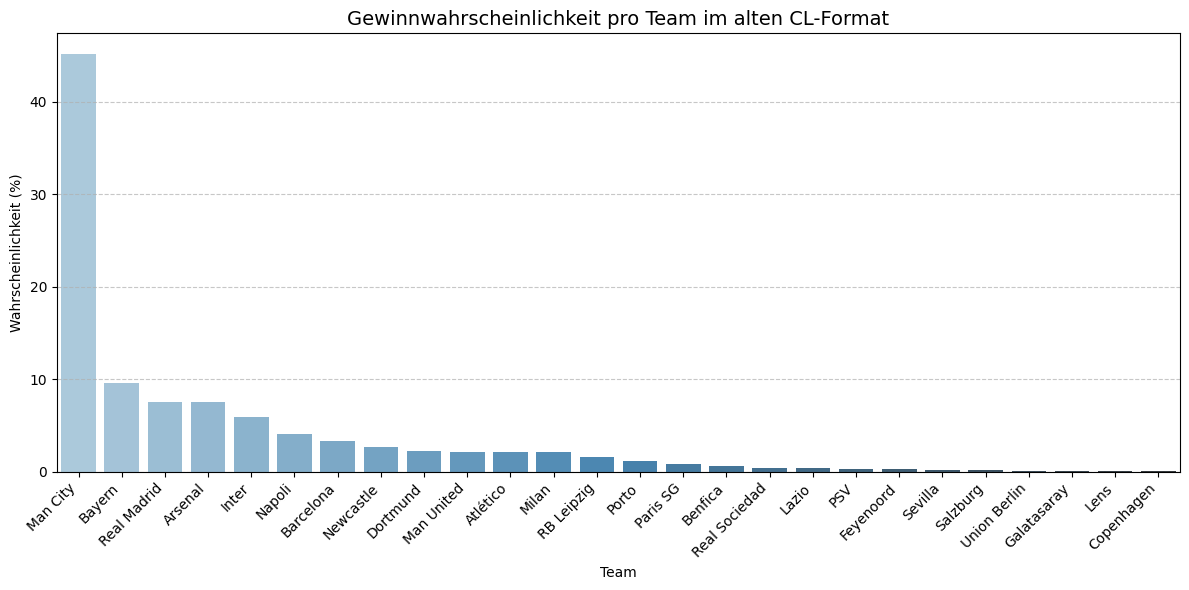

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sicherstellen, dass du 'results_df' aus der Simulation hast
# Beispiel: results_df = pd.DataFrame.from_dict(winner_counts, orient="index", columns=["Wins"]).sort_values(by="Wins", ascending=False)

# Umwandeln in Prozentwerte
total_simulations = results_df["Wins"].sum()
results_df["Win Probability (%)"] = (results_df["Wins"] / total_simulations) * 100
results_df = results_df.reset_index().rename(columns={"index": "Team"})

# Sortieren
results_df = results_df.sort_values("Win Probability (%)", ascending=False)

# Balkendiagramm
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Team", y="Win Probability (%)", palette="Blues_d")
plt.title("Gewinnwahrscheinlichkeit pro Team im alten CL-Format", fontsize=14)
plt.ylabel("Wahrscheinlichkeit (%)")
plt.xlabel("Team")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\salim\AppData\Local\Temp\ipykernel_5816\471702391.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Team", y="Win Probability (%)", palette="Blues_d")


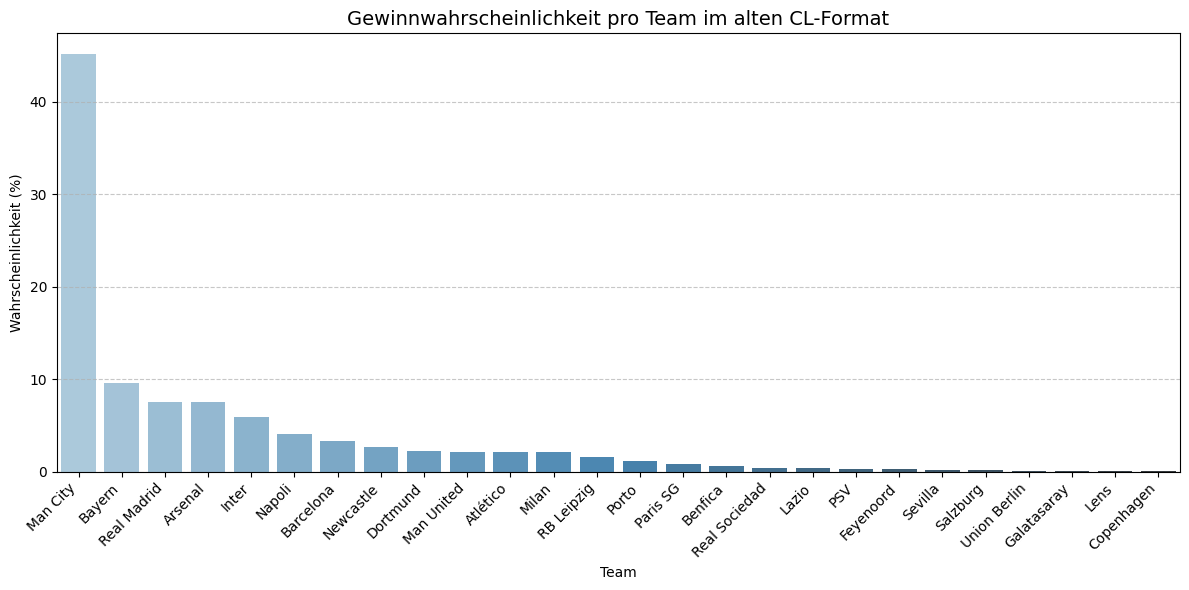

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prozent berechnen
total_simulations = results_df["Wins"].sum()
results_df["Win Probability (%)"] = (results_df["Wins"] / total_simulations) * 100

# Sortieren nach Wahrscheinlichkeit
results_df = results_df.sort_values("Win Probability (%)", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Team", y="Win Probability (%)", palette="Blues_d")
plt.title("Gewinnwahrscheinlichkeit pro Team im alten CL-Format", fontsize=14)
plt.ylabel("Wahrscheinlichkeit (%)")
plt.xlabel("Team")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\salim\AppData\Local\Temp\ipykernel_5816\3660801851.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\salim\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


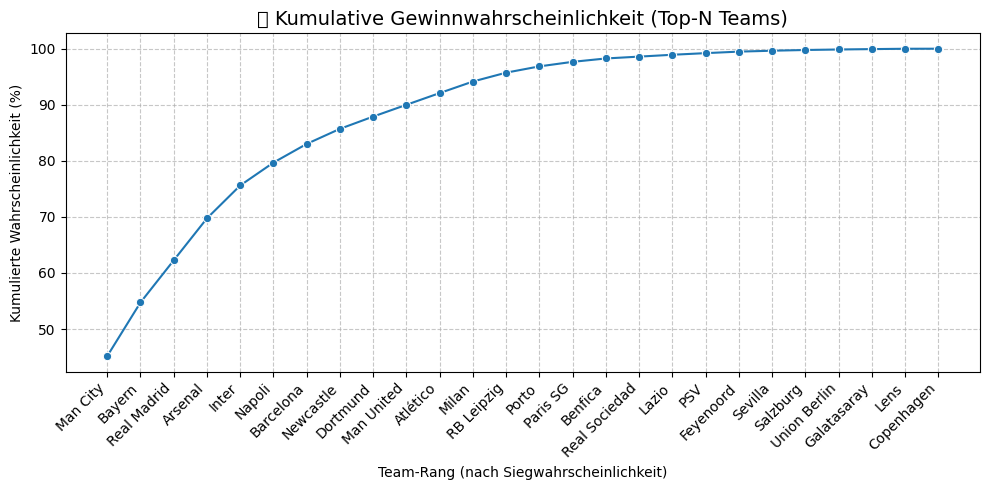

In [101]:
# Cumulative sum plot
results_df_sorted = results_df.sort_values("Win Probability (%)", ascending=False).reset_index(drop=True)
results_df_sorted["Cumulative"] = results_df_sorted["Win Probability (%)"].cumsum()

plt.figure(figsize=(10, 5))
sns.lineplot(data=results_df_sorted, x=results_df_sorted.index + 1, y="Cumulative", marker="o")
plt.xticks(ticks=range(1, len(results_df_sorted)+1), labels=results_df_sorted["Team"], rotation=45, ha="right")
plt.title("📈 Kumulative Gewinnwahrscheinlichkeit (Top-N Teams)", fontsize=14)
plt.xlabel("Team-Rang (nach Siegwahrscheinlichkeit)")
plt.ylabel("Kumulierte Wahrscheinlichkeit (%)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [102]:
from collections import Counter
import pandas as pd

# Fortschrittszähler initialisieren
progress = {
    "Round of 16": Counter(),
    "Quarter-finals": Counter(),
    "Semi-finals": Counter(),
    "Final": Counter(),
    "Champion": Counter()
}

n_simulations = 10000  # oder z. B. 10000

for sim in range(n_simulations):
    group_matches = simulate_group_stage(df_group_draw)
    pts, gd = compute_group_points(group_matches)

    teams_in_groups = df_group_draw.copy()
    teams_in_groups["Points"] = teams_in_groups["Club"].map(pts).fillna(0)
    teams_in_groups["GD"] = teams_in_groups["Club"].map(gd).fillna(0)

    qualified = []
    for group in teams_in_groups["Group"].unique():
        top2 = (
            teams_in_groups[teams_in_groups["Group"] == group]
            .sort_values(by=["Points", "GD"], ascending=False)
            .head(2)["Club"]
            .tolist()
        )
        qualified.extend(top2)

    for team in qualified:
        progress["Round of 16"][team] += 1

    qf = simulate_knockout_round(qualified, df_group_draw)
    for team in qf:
        progress["Quarter-finals"][team] += 1

    sf = simulate_knockout_round(qf, df_group_draw)
    for team in sf:
        progress["Semi-finals"][team] += 1

    finalists = simulate_knockout_round(sf, df_group_draw)
    for team in finalists:
        progress["Final"][team] += 1

    winner = simulate_final(finalists[0], finalists[1], df_group_draw)
    progress["Champion"][winner] += 1

# === Wahrscheinlichkeiten berechnen ===
teams = set()
for stage in progress:
    teams.update(progress[stage].keys())

elo_map = df_group_draw.set_index("Club")["Elo"].to_dict()

table = []
for team in sorted(teams):
    row = {
        "Team": team,
        "Elo": elo_map.get(team, None)
    }
    for stage in ["Round of 16", "Quarter-finals", "Semi-finals", "Final", "Champion"]:
        count = progress[stage].get(team, 0)
        percentage = (count / n_simulations) * 100
        row[stage] = "<1%" if percentage < 0.5 else f"{percentage:.0f}%"
    table.append(row)

df_probabilities = pd.DataFrame(table)

# === Sortieren nach Elo (stärkstes Team oben) ===
df_probabilities = (
    df_probabilities
    .sort_values(by="Elo", ascending=False)
    .reset_index(drop=True)
)[["Team", "Elo", "Round of 16", "Quarter-finals", "Semi-finals", "Final", "Champion"]]

# === MultiIndex für Gruppierung der Spaltenüberschriften (wie im Bild) ===
new_columns = pd.MultiIndex.from_tuples([
    ("", "Team"),
    ("Team Rating", "Elo"),
    ("Chances To Reach Knockout Stage", "Round of 16"),
    ("Chances To Reach Knockout Stage", "Quarter-finals"),
    ("Chances To Reach Knockout Stage", "Semi-finals"),
    ("Chances To Reach Knockout Stage", "Final"),
    ("Chances To Reach Knockout Stage", "Champion")
])
df_probabilities.columns = new_columns

# === Styling-Funktion für grüne Zellen ===
def style_probabilities_multiindex(df):
    def color_map(val):
        if val == "<1%":
            val_num = 0.4
        else:
            val_num = float(val.strip('%'))
        green = int(255 - (val_num / 100) * 150)
        return f"background-color: rgb({green}, 255, {green});"

    probability_cols = df.columns[2:]
    
    return (
        df.style.format({col: lambda x: x for col in probability_cols})
          .applymap(color_map, subset=probability_cols)
          .set_properties(**{'text-align': 'center', 'font-weight': 'bold'})
          .set_table_styles([
              {"selector": "th", "props": [
                  ("background-color", "#f2f2f2"),
                  ("font-weight", "bold"),
                  ("text-align", "center")
              ]}
          ])
    )


# === Darstellung anzeigen ===
styled_df = style_probabilities_multiindex(df_probabilities)
display(styled_df)


C:\Users\salim\AppData\Local\Temp\ipykernel_5816\3185161299.py:105: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_map, subset=probability_cols)


In [103]:
html_str = styled_df.to_html()

with open("knockout_table.html", "w", encoding="utf-8") as f:
    f.write(html_str)

print("✅ Datei 'knockout_table.html' gespeichert – einfach öffnen & als PDF drucken.")


✅ Datei 'knockout_table.html' gespeichert – einfach öffnen & als PDF drucken.


In [104]:
import pandas as pd

# Pot-Zuweisung für Szenario A (Man United in Pot 2)
teams_with_pots_pot2 = [
    # Pot 1
    ("Man City", 1), ("Sevilla", 1), ("Barcelona", 1), ("Napoli", 1),
    ("Bayern", 1), ("Paris SG", 1), ("Benfica", 1), ("Feyenoord", 1),
    # Pot 2 (inkl. Man United)
    ("Real Madrid", 2), ("Man United", 2), ("Inter", 2), ("Dortmund", 2),
    ("Atlético", 2), ("RB Leipzig", 2), ("Porto", 2), ("Arsenal", 2),
    # Pot 3
    ("Shakhtar", 3), ("Salzburg", 3), ("Milan", 3), ("Braga", 3),
    ("PSV", 3), ("Lazio", 3), ("Crvena Zvezda", 3), ("Copenhagen", 3),
    # Pot 4
    ("Young Boys", 4), ("Real Sociedad", 4), ("Galatasaray", 4), ("Celtic", 4),
    ("Newcastle", 4), ("Union Berlin", 4), ("Antwerp", 4), ("Lens", 4),
]

# ELO-Werte
elo_dict = {
    "Man City": 2091, "Sevilla": 1733, "Barcelona": 1878, "Napoli": 1892,
    "Bayern": 1940, "Paris SG": 1801, "Benfica": 1806, "Feyenoord": 1753,
    "Real Madrid": 1922, "Man United": 1847, "Inter": 1909, "Dortmund": 1841,
    "Atlético": 1838, "RB Leipzig": 1841, "Porto": 1825, "Arsenal": 1932,
    "Shakhtar": 1591, "Salzburg": 1730, "Milan": 1841, "Braga": 1662,
    "PSV": 1778, "Lazio": 1760, "Crvena Zvezda": 1573, "Copenhagen": 1632,
    "Young Boys": 1630, "Real Sociedad": 1772, "Galatasaray": 1696,
    "Celtic": 1634, "Newcastle": 1872, "Union Berlin": 1735,
    "Antwerp": 1656, "Lens": 1709
}

# Länderzuordnung
club_to_country = {
    "Man City": "ENG", "Sevilla": "ESP", "Barcelona": "ESP", "Napoli": "ITA", "Bayern": "GER", "Paris SG": "FRA", "Benfica": "POR", "Feyenoord": "NED",
    "Real Madrid": "ESP", "Man United": "ENG", "Inter": "ITA", "Dortmund": "GER", "Atlético": "ESP", "RB Leipzig": "GER", "Porto": "POR", "Arsenal": "ENG",
    "Shakhtar": "UKR", "Salzburg": "AUT", "Milan": "ITA", "Braga": "POR", "PSV": "NED", "Lazio": "ITA", "Crvena Zvezda": "SRB", "Copenhagen": "DEN",
    "Young Boys": "SUI", "Real Sociedad": "ESP", "Galatasaray": "TUR", "Celtic": "SCO", "Newcastle": "ENG", "Union Berlin": "GER", "Antwerp": "BEL", "Lens": "FRA"
}

# DataFrame erstellen
df_pots_pot2 = pd.DataFrame(teams_with_pots_pot2, columns=["Club", "Pot"])
df_pots_pot2["Elo"] = df_pots_pot2["Club"].map(elo_dict)
df_pots_pot2["Country"] = df_pots_pot2["Club"].map(club_to_country)


In [105]:
df_pots_pot2

,Club,Pot,Elo,Country
0,Man City,1,2091,ENG
1,Sevilla,1,1733,ESP
2,Barcelona,1,1878,ESP
3,Napoli,1,1892,ITA
4,Bayern,1,1940,GER
5,Paris SG,1,1801,FRA
6,Benfica,1,1806,POR
7,Feyenoord,1,1753,NED
8,Real Madrid,2,1922,ESP
9,Man United,2,1847,ENG


In [106]:
import pandas as pd

# Pot-Zuweisung für Szenario B (Man United in Pot 3, Milan geht in Pot 2)
teams_with_pots_pot3 = [
    # Pot 1
    ("Man City", 1), ("Sevilla", 1), ("Barcelona", 1), ("Napoli", 1),
    ("Bayern", 1), ("Paris SG", 1), ("Benfica", 1), ("Feyenoord", 1),
    # Pot 2 (Milan hochgestuft)
    ("Real Madrid", 2), ("Milan", 2), ("Inter", 2), ("Dortmund", 2),
    ("Atlético", 2), ("RB Leipzig", 2), ("Porto", 2), ("Arsenal", 2),
    # Pot 3 (Man United in Pot 3)
    ("Shakhtar", 3), ("Salzburg", 3), ("Man United", 3), ("Braga", 3),
    ("PSV", 3), ("Lazio", 3), ("Crvena Zvezda", 3), ("Copenhagen", 3),
    # Pot 4
    ("Young Boys", 4), ("Real Sociedad", 4), ("Galatasaray", 4), ("Celtic", 4),
    ("Newcastle", 4), ("Union Berlin", 4), ("Antwerp", 4), ("Lens", 4),
]

# ELO-Werte (identisch)
elo_dict = {
    "Man City": 2091, "Sevilla": 1733, "Barcelona": 1878, "Napoli": 1892,
    "Bayern": 1940, "Paris SG": 1801, "Benfica": 1806, "Feyenoord": 1753,
    "Real Madrid": 1922, "Man United": 1847, "Inter": 1909, "Dortmund": 1841,
    "Atlético": 1838, "RB Leipzig": 1841, "Porto": 1825, "Arsenal": 1932,
    "Shakhtar": 1591, "Salzburg": 1730, "Milan": 1841, "Braga": 1662,
    "PSV": 1778, "Lazio": 1760, "Crvena Zvezda": 1573, "Copenhagen": 1632,
    "Young Boys": 1630, "Real Sociedad": 1772, "Galatasaray": 1696,
    "Celtic": 1634, "Newcastle": 1872, "Union Berlin": 1735,
    "Antwerp": 1656, "Lens": 1709
}

# Länderzuordnung
club_to_country = {
    "Man City": "ENG", "Sevilla": "ESP", "Barcelona": "ESP", "Napoli": "ITA", "Bayern": "GER", "Paris SG": "FRA", "Benfica": "POR", "Feyenoord": "NED",
    "Real Madrid": "ESP", "Man United": "ENG", "Inter": "ITA", "Dortmund": "GER", "Atlético": "ESP", "RB Leipzig": "GER", "Porto": "POR", "Arsenal": "ENG",
    "Shakhtar": "UKR", "Salzburg": "AUT", "Milan": "ITA", "Braga": "POR", "PSV": "NED", "Lazio": "ITA", "Crvena Zvezda": "SRB", "Copenhagen": "DEN",
    "Young Boys": "SUI", "Real Sociedad": "ESP", "Galatasaray": "TUR", "Celtic": "SCO", "Newcastle": "ENG", "Union Berlin": "GER", "Antwerp": "BEL", "Lens": "FRA"
}

# DataFrame erstellen
df_pots_pot3 = pd.DataFrame(teams_with_pots_pot3, columns=["Club", "Pot"])
df_pots_pot3["Elo"] = df_pots_pot3["Club"].map(elo_dict)
df_pots_pot3["Country"] = df_pots_pot3["Club"].map(club_to_country)


In [107]:
df_pots_pot3

,Club,Pot,Elo,Country
0,Man City,1,2091,ENG
1,Sevilla,1,1733,ESP
2,Barcelona,1,1878,ESP
3,Napoli,1,1892,ITA
4,Bayern,1,1940,GER
5,Paris SG,1,1801,FRA
6,Benfica,1,1806,POR
7,Feyenoord,1,1753,NED
8,Real Madrid,2,1922,ESP
9,Milan,2,1841,ITA


In [108]:
import numpy as np
import math
from itertools import combinations
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Parameter ===
SIMULATIONS = 500
TEAM_NAME = "Man United"

# === Poisson-Koeffizienten ===
beta0 = 0.2289
beta_elo = 0.0020
beta_home = 0.2019

# === Erwartete Tore berechnen ===
def expected_goals(elo_diff, home_dummy):
    return math.exp(beta0 + beta_elo * elo_diff + beta_home * home_dummy)

# === Gruppenauslosung (einfach: ignoriert Länderduplikate) ===
def create_group_draw(df_base):
    df = df_base.copy()
    groups = {f"Group {chr(65+i)}": [] for i in range(8)}
    
    for pot_num in range(1, 5):
        pot_teams = df[df["Pot"] == pot_num].sample(frac=1).to_dict("records")
        for i, team in enumerate(pot_teams):
            groups[f"Group {chr(65 + (i % 8))}"].append(team)
    
    rows = []
    for group, teams in groups.items():
        for team in teams:
            rows.append({
                "Group": group,
                "Club": team["Club"],
                "Country": team["Country"],
                "Pot": team["Pot"],
                "Elo": team["Elo"]
            })
    return pd.DataFrame(rows)

# === Gruppenphase simulieren ===
def simulate_group_stage(df_group_draw):
    results = []
    grouped = df_group_draw.groupby("Group")

    for _, teams in grouped:
        for team1, team2 in combinations(teams.to_dict("records"), 2):
            elo1, elo2 = team1["Elo"], team2["Elo"]
            g1 = np.random.poisson(expected_goals(elo1 - elo2, 1))
            g2 = np.random.poisson(expected_goals(elo2 - elo1, 0))
            results.append((team1["Club"], team2["Club"], g1, g2))

            g3 = np.random.poisson(expected_goals(elo2 - elo1, 1))
            g4 = np.random.poisson(expected_goals(elo1 - elo2, 0))
            results.append((team2["Club"], team1["Club"], g3, g4))

    points = defaultdict(int)
    goal_diff = defaultdict(int)
    for h, a, gh, ga in results:
        if gh > ga:
            points[h] += 3
        elif gh < ga:
            points[a] += 3
        else:
            points[h] += 1
            points[a] += 1
        goal_diff[h] += gh - ga
        goal_diff[a] += ga - gh

    df_group_draw["Points"] = df_group_draw["Club"].map(points)
    df_group_draw["GD"] = df_group_draw["Club"].map(goal_diff)

    qualified = []
    for group in df_group_draw["Group"].unique():
        top2 = (
            df_group_draw[df_group_draw["Group"] == group]
            .sort_values(by=["Points", "GD"], ascending=False)
            .head(2)["Club"]
            .tolist()
        )
        qualified.extend(top2)

    return TEAM_NAME in qualified

# === Hauptfunktion für Gruppensimulation eines DataFrames ===
def run_group_stage_analysis(df_with_pots):
    qualified_count = 0
    for _ in range(SIMULATIONS):
        draw = create_group_draw(df_with_pots)
        if simulate_group_stage(draw):
            qualified_count += 1
    return qualified_count

# ✅ Jetzt ausführen – beide DataFrames müssen existieren
qualified_pot2 = run_group_stage_analysis(df_pots_pot2)
qualified_pot3 = run_group_stage_analysis(df_pots_pot3)

# 📊 Ergebnis anzeigen
results_df = pd.DataFrame({
    "Szenario": ["Man United in Pot 2", "Man United in Pot 3"],
    "Gruppenphase überstanden": [qualified_pot2, qualified_pot3],
    "Total Simulationen": [SIMULATIONS, SIMULATIONS],
    "Erfolgsquote (%)": [qualified_pot2 / SIMULATIONS * 100, qualified_pot3 / SIMULATIONS * 100]
})


# 🧾 Ergebnis anzeigen
results_df


,Szenario,Gruppenphase überstanden,Total Simulationen,Erfolgsquote (%)
0,Man United in Pot 2,361,500,72.2
1,Man United in Pot 3,282,500,56.4


C:\Users\salim\AppData\Local\Temp\ipykernel_5816\2414559531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Szenario", y="Erfolgsquote (%)", palette="coolwarm")


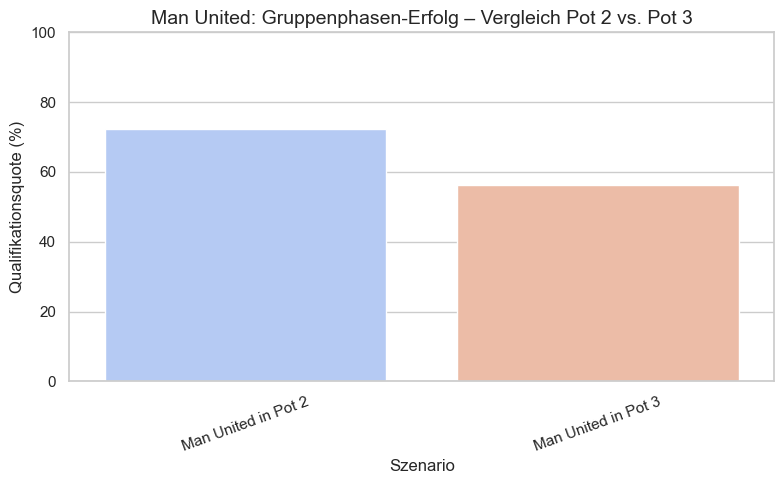

In [109]:
# 📈 Visualisierung
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Szenario", y="Erfolgsquote (%)", palette="coolwarm")
plt.title(f"{TEAM_NAME}: Gruppenphasen-Erfolg – Vergleich Pot 2 vs. Pot 3", fontsize=14)
plt.ylabel("Qualifikationsquote (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## BSP:
Man U im alten Format Pot 2 und Pot 3, und dann Man U im neuen Format in Pot 2 und 3 ; und dann die Gewinnchancen vergleichen, gibt es mehr Ge.chancen?